# Convolutional Neural Networks

# Importar Librerías

In [58]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [59]:
import keras
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import (
 #   BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
#)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [60]:
dirname = os.path.join(os.getcwd(),'sportimages')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            if len(image.shape)==3:
                images.append(image)
                b = "Leyendo..." + str(cant)
            #print (b, end="\r")
            if prevRoot !=root:
                #print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

leyendo imagenes de  /home/punch/IA/JUPYTER/sportimages/
Directorios leidos: 10
Imagenes en cada directorio [9769, 8937, 7752, 5053, 7617, 7533, 9348, 8823, 7125, 5171]
suma Total de imagenes en subdirs: 77128


# Creamos las etiquetas

In [61]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  77128


In [62]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 golf
1 tenis
2 beisball
3 f1
4 futbol
5 ciclismo
6 americano
7 basket
8 boxeo
9 natacion


In [63]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


# Creamos Sets de Entrenamiento y Test

In [64]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (61702, 21, 28, 3) (61702,)
Testing data shape :  (15426, 21, 28, 3) (15426,)


Text(0.5, 1.0, 'Ground Truth : 8')

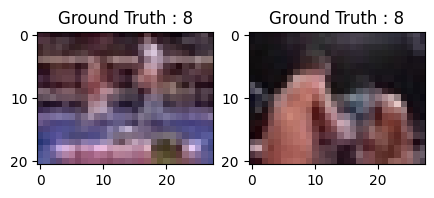

In [65]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

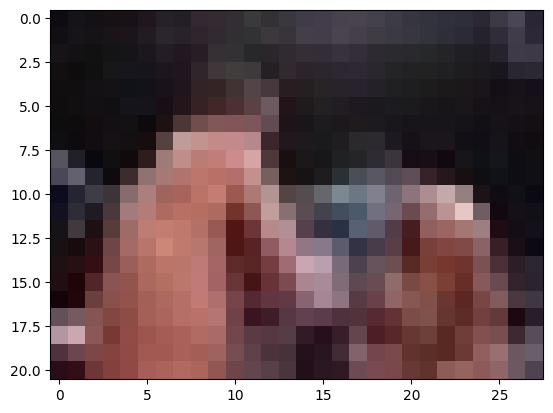

In [66]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [67]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 8
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


# Creamos el Set de Entrenamiento y Validación

In [68]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=48)

In [69]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(49361, 21, 28, 3) (12341, 21, 28, 3) (49361, 10) (12341, 10)


# Creamos el modelo de CNN

In [70]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 10
epochs = 20 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [71]:
sport_model = Sequential()
sport_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear', padding='same', input_shape=(28,21,3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2),padding='same'))
sport_model.add(Dropout(0.5))

                              
sport_model.add(Flatten())
sport_model.add(Dense(32, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

/home/punch/IA/JUPYTER/.env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/punch/IA/JUPYTER/.env/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [72]:
sport_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 21, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,954 (620.91 KB)

 Trainable params: 158,954 (620.91 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
sport_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.SGD(learning_rate=INIT_LR),metrics=['accuracy'])

# Entrenamos el modelo: Aprende a clasificar imágenes

In [74]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label))

Epoch 1/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.1688 - loss: 2.2321 - val_accuracy: 0.3333 - val_loss: 2.0917
Epoch 2/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.2579 - loss: 2.0674 - val_accuracy: 0.3949 - val_loss: 1.8692
Epoch 3/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3206 - loss: 1.9077 - val_accuracy: 0.5206 - val_loss: 1.6809
Epoch 4/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3808 - loss: 1.7719 - val_accuracy: 0.5795 - val_loss: 1.5286
Epoch 5/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4281 - loss: 1.6551 - val_accuracy: 0.6125 - val_loss: 1.4063
Epoch 6/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4650 - loss: 1.5547 - val_accuracy: 0.6278 - val_loss: 1.2932
Epoch 7/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4956 - loss: 1.4704 - val_accuracy: 0.6595 - val_loss: 1.2075
Epoch 8/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5191 - loss: 1.3947 - 

In [75]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("salida/riesgo1.keras")

# Evaluamos la red

In [76]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8278 - loss: 0.6734


In [77]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.673367977142334
Test accuracy: 0.8277583122253418


In [78]:
sport_train.history

{'accuracy': [0.1687769740819931,
  0.2579161822795868,
  0.32059723138809204,
  0.3808472156524658,
  0.4280707538127899,
  0.4649622142314911,
  0.4955734312534332,
  0.5190940499305725,
  0.5427767038345337,
  0.5622860193252563,
  0.5817548036575317,
  0.5991774797439575,
  0.613946259021759,
  0.6276412606239319,
  0.6436862945556641,
  0.6532687544822693,
  0.6621826887130737,
  0.6734466552734375,
  0.6861084699630737,
  0.6961163878440857],
 'loss': [2.232130289077759,
  2.0673601627349854,
  1.9077380895614624,
  1.7718865871429443,
  1.6550885438919067,
  1.5546880960464478,
  1.4704283475875854,
  1.3947303295135498,
  1.3277539014816284,
  1.2722305059432983,
  1.2156956195831299,
  1.1723747253417969,
  1.1297636032104492,
  1.0905741453170776,
  1.0548864603042603,
  1.0240113735198975,
  0.9962260723114014,
  0.9748849868774414,
  0.9447782635688782,
  0.919457197189331],
 'val_accuracy': [0.3332793116569519,
  0.39486265182495117,
  0.5206223130226135,
  0.5795316696166

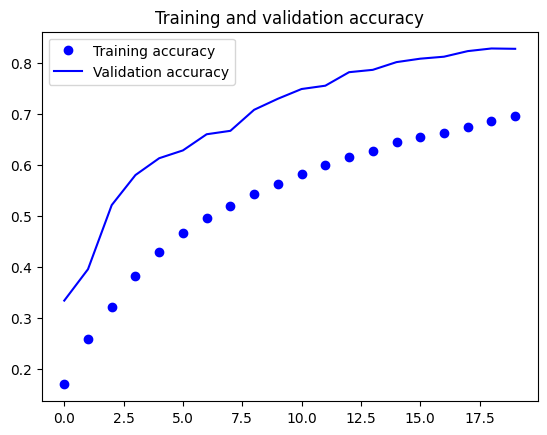

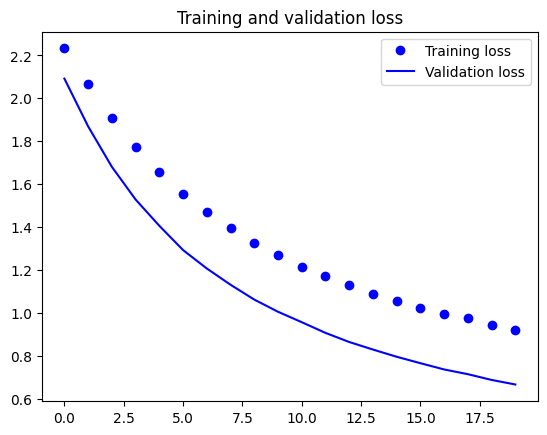

In [79]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [80]:
predicted_classes2 = sport_model.predict(test_X)

483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [81]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [82]:
predicted_classes.shape, test_Y.shape

((15426,), (15426,))

# Aprendamos de los errores: Qué mejorar

Found 12769 correct labels


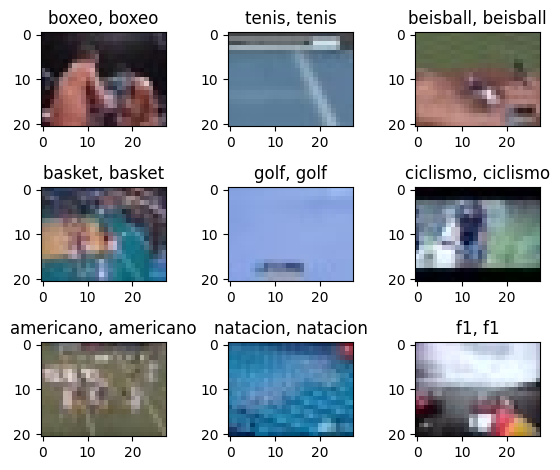

In [83]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 2657 incorrect labels


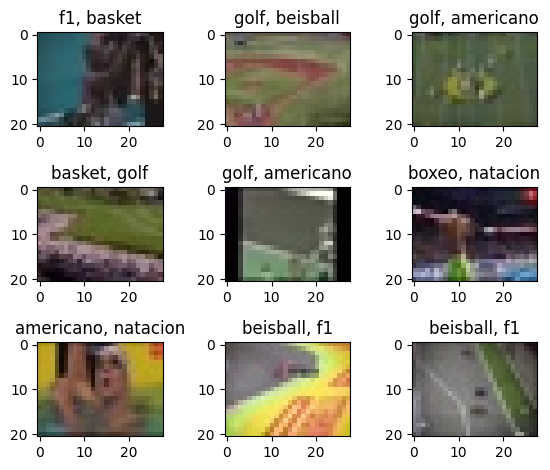

In [84]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [85]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.66      0.89      0.76      1973
     Class 1       0.99      1.00      0.99      1726
     Class 2       0.81      0.69      0.74      1577
     Class 3       0.77      0.39      0.52      1015
     Class 4       0.91      0.83      0.87      1547
     Class 5       0.97      0.99      0.98      1543
     Class 6       0.68      0.63      0.66      1851
     Class 7       0.80      0.91      0.85      1759
     Class 8       0.89      0.90      0.89      1400
     Class 9       0.93      0.92      0.92      1035

    accuracy                           0.83     15426
   macro avg       0.84      0.82      0.82     15426
weighted avg       0.83      0.83      0.82     15426



In [ ]:
from skimage.transform import resize

images=[]
# AQUI ESPECIFICAMOS UNAS IMAGENES
filenames = ['jpeg.jpg']

for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = resize(image, (21, 28),anti_aliasing=True,clip=False,preserve_range=True)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = sport_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], deportes[img_tagged.tolist().index(max(img_tagged))])

FileNotFoundError: [Errno 2] No such file or directory: 'eje.jpg'